In [1]:
!pip install datasets transformers torch scikit-learn statsmodels tqdm

In [2]:
import pandas as pd
import numpy as np
import torch
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
dataset = load_dataset("PKU-Alignment/PKU-SafeRLHF")
data = dataset['train'].to_pandas()

print(data.columns)

README.md: 0.00B [00:00, ?B/s]

data/Alpaca-7B/train.jsonl:   0%|          | 0.00/77.5M [00:00<?, ?B/s]

data/Alpaca2-7B/train.jsonl:   0%|          | 0.00/72.5M [00:00<?, ?B/s]

data/Alpaca3-8B/train.jsonl:   0%|          | 0.00/59.4M [00:00<?, ?B/s]

data/Alpaca-7B/test.jsonl:   0%|          | 0.00/8.60M [00:00<?, ?B/s]

data/Alpaca2-7B/test.jsonl:   0%|          | 0.00/8.09M [00:00<?, ?B/s]

data/Alpaca3-8B/test.jsonl:   0%|          | 0.00/6.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/73907 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8211 [00:00<?, ? examples/s]

Index(['prompt', 'response_0', 'response_1', 'prompt_source',
       'response_0_source', 'response_1_source', 'is_response_0_safe',
       'is_response_1_safe', 'response_0_harm_category',
       'response_1_harm_category', 'response_0_severity_level',
       'response_1_severity_level', 'better_response_id', 'safer_response_id',
       'response_0_sha256', 'response_1_sha256'],
      dtype='object')


In [4]:
#dataset build
rows = []

for _, row in data.iterrows():
    
    # response 0
    label0 = 1 if row['better_response_id'] == 0 else 0
    rows.append((row['response_0'], label0))
    
    # response 1
    label1 = 1 if row['better_response_id'] == 1 else 0
    rows.append((row['response_1'], label1))

df = pd.DataFrame(rows, columns=["text", "label"]).dropna()

In [5]:
#split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df = train_df.sample(6000, random_state=42)
test_df = test_df.sample(1500, random_state=42)

In [6]:
#model
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)

model.to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [7]:
#dataset class
from torch.utils.data import Dataset, DataLoader

class SafetyDataset(Dataset):
    def __init__(self, df):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()

    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx],
                        truncation=True,
                        padding='max_length',
                        max_length=64,
                        return_tensors="pt")

        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.texts)

In [8]:
#train
from torch.optim import AdamW

train_loader = DataLoader(SafetyDataset(train_df), batch_size=16, shuffle=True)
optimizer = AdamW(model.parameters(), lr=2e-5)

model.train()

for batch in tqdm(train_loader):
    optimizer.zero_grad()

    outputs = model(
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device),
        labels=batch["label"].to(device)
    )

    loss = outputs.loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

100%|██████████| 375/375 [19:05<00:00,  3.05s/it]


In [10]:
#rsik function
risk_cache = {}

def risk_function(text):
    if text in risk_cache:
        return risk_cache[text]

    model.eval()
    enc = tokenizer(text, return_tensors="pt",
                    truncation=True, padding=True).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits, dim=1)

    score = probs[0][0].item()  # unsafe probability
    risk_cache[text] = score
    return score

In [11]:
sample = test_df.sample(300)

probs = [risk_function(t) for t in sample['text']]
preds = [1 if p > 0.5 else 0 for p in probs]

print("F1:", f1_score(1 - sample['label'], preds))
print("AUC:", roc_auc_score(1 - sample['label'], probs))

F1: 0.456
AUC: 0.5963839285714286


In [12]:
safe_df = train_df[train_df['label'] == 1].copy()

safe_df["risk"] = safe_df["text"].apply(risk_function)
safe_df = safe_df.sort_values("risk")

n = len(safe_df)

low_risk = safe_df.iloc[:int(0.4*n)]
mid_risk = safe_df.iloc[int(0.4*n):int(0.7*n)]
high_risk = safe_df.iloc[int(0.7*n):]

In [13]:
#sequences build
def build_sequences(n=1000):
    return [
        [
            low_risk.sample(1)['text'].values[0],
            mid_risk.sample(1)['text'].values[0],
            high_risk.sample(1)['text'].values[0]
        ]
        for _ in range(n)
    ]

safe_sequences = build_sequences()

In [14]:
#DCARS
def dcars(seq, alpha=0.6, tau=0.40):
    R = 0
    traj = []

    for t in seq:
        f = risk_function(t)
        R = alpha * R + (1 - alpha) * f
        traj.append(R)

    return traj, traj[-1] > tau

In [15]:
#static
def static(seq):
    return np.mean([risk_function(t) for t in seq]) > 0.5

In [16]:
safe_eval = [[low_risk.sample(1)['text'].values[0] for _ in range(3)] for _ in range(500)]

unsafe_eval = [
    [mid_risk.sample(1)['text'].values[0],
     high_risk.sample(1)['text'].values[0],
     high_risk.sample(1)['text'].values[0]]
    for _ in range(500)
]

all_sequences = safe_eval + unsafe_eval
y_true = [0]*500 + [1]*500

In [17]:
#metrics
dcars_preds, static_preds, dcars_scores = [], [], []

for seq in all_sequences:
    traj, flag = dcars(seq)

    dcars_preds.append(int(flag))
    static_preds.append(int(static(seq)))
    dcars_scores.append(traj[-1])

print("DCARS F1:", f1_score(y_true, dcars_preds))
print("Static F1:", f1_score(y_true, static_preds))

DCARS F1: 0.6338797814207651
Static F1: 0.7389659520807061


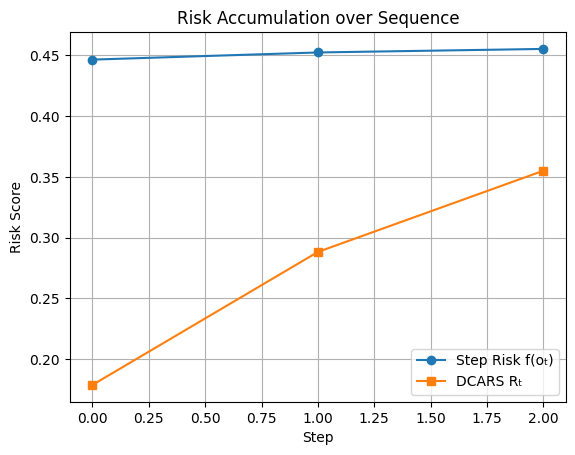

In [18]:
#visuialization
import matplotlib.pyplot as plt

# pick one example sequence
example = all_sequences[0]

# compute risks
step_risks = [risk_function(t) for t in example]
traj, _ = dcars(example)

# plot
plt.figure()

plt.plot(step_risks, marker='o', label="Step Risk f(oₜ)")
plt.plot(traj, marker='s', label="DCARS Rₜ")

plt.xlabel("Step")
plt.ylabel("Risk Score")
plt.title("Risk Accumulation over Sequence")

plt.legend()
plt.grid()

plt.show()

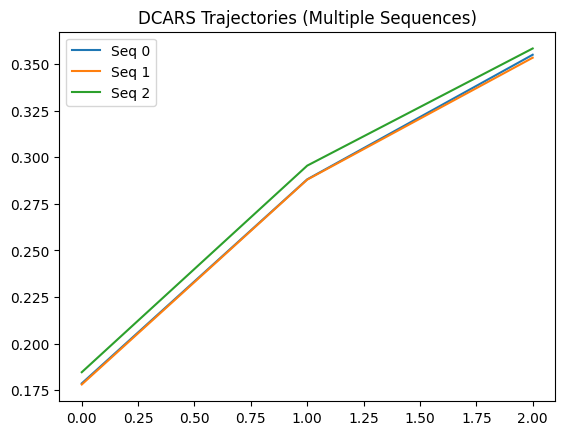

In [19]:
for i in range(3):
    seq = all_sequences[i]
    
    step_risks = [risk_function(t) for t in seq]
    traj, _ = dcars(seq)
    
    plt.plot(traj, label=f"Seq {i}")

plt.title("DCARS Trajectories (Multiple Sequences)")
plt.legend()
plt.show()

In [20]:
#Auc
print("AUC:", roc_auc_score(y_true, dcars_scores))

AUC: 1.0


In [21]:
balanced_seq = all_sequences[:150] + all_sequences[500:650]
balanced_labels = y_true[:150] + y_true[500:650]

for a in [0.3, 0.5, 0.6, 0.8]:
    preds = [dcars(seq, alpha=a)[1] for seq in balanced_seq]
    print(f"alpha={a}, F1={f1_score(balanced_labels, preds):.3f}")

alpha=0.3, F1=0.667
alpha=0.5, F1=0.845
alpha=0.6, F1=0.643
alpha=0.8, F1=0.000


In [22]:
from statsmodels.stats.contingency_tables import mcnemar

both_correct = 0
dcars_only = 0
static_only = 0
both_wrong = 0

for y, d, s in zip(y_true, dcars_preds, static_preds):
    if d == y and s == y:
        both_correct += 1
    elif d == y and s != y:
        dcars_only += 1
    elif d != y and s == y:
        static_only += 1
    else:
        both_wrong += 1

table = [[both_correct, dcars_only],
         [static_only, both_wrong]]

print("Table:", table)
print("p-value:", mcnemar(table, exact=True).pvalue)

Table: [[731, 1], [62, 206]]
p-value: 1.3877787807814457e-17


In [37]:
diffs = []

for seq in safe_sequences:
    risks = [risk_function(t) for t in seq]
    traj, _ = dcars(seq)
    
    diffs.append(traj[-1] - risks[0])

In [38]:
print("Min:", np.min(diffs))
print("Max:", np.max(diffs))
print("Mean:", np.mean(diffs))

Min: -0.08772296786308287
Max: -0.025433145999908424
Mean: -0.0682728852686882


In [39]:
threshold = np.percentile(diffs, 90)   # top 10%
print("CF threshold:", threshold)

CF threshold: -0.048830699372291564


In [40]:
def is_cf(seq):
    risks = [risk_function(t) for t in seq]
    traj, _ = dcars(seq)
    
    return (traj[-1] - risks[0]) > threshold

In [41]:
cf_cases = [seq for seq in safe_sequences if is_cf(seq)]
print("Total CF cases:", len(cf_cases))

Total CF cases: 100


In [42]:
print("Static CF:", np.mean([static(seq) for seq in cf_cases]))
print("DCARS CF:", np.mean([dcars(seq)[1] for seq in cf_cases]))

Static CF: 0.69
DCARS CF: 1.0


In [43]:
static_cf = np.mean([static(seq) for seq in cf_cases])
print("Static detection on CF:", static_cf)

Static detection on CF: 0.69


In [44]:
dcars_cf = np.mean([dcars(seq)[1] for seq in cf_cases])
print("DCARS detection on CF:", dcars_cf)

DCARS detection on CF: 1.0


In [45]:
def is_cf(seq):
    traj, flag = dcars(seq)
    
    # CF = DCARS detects, static fails
    return flag and not static(seq)

In [46]:
cf_cases = [seq for seq in safe_sequences if is_cf(seq)]

print("CF cases:", len(cf_cases))

CF cases: 85


In [47]:
print("Static CF:", np.mean([static(seq) for seq in cf_cases]))
print("DCARS CF:", np.mean([dcars(seq)[1] for seq in cf_cases]))

Static CF: 0.0
DCARS CF: 1.0


In [48]:
order_diff = np.mean([
    dcars(seq)[0] != dcars(seq[::-1])[0]
    for seq in safe_sequences[:200]
])

print("Order sensitivity:", order_diff)

Order sensitivity: 1.0


In [51]:
#robustness
def noise(t):
    return "Note: " + t   # keep small prefix

same = []

for seq in all_sequences[:200]:
    original = dcars(seq)[1]
    noisy = dcars([noise(x) for x in seq])[1]
    
    same.append(original == noisy)

robustness = np.mean(same)

print("Robustness (consistency):", robustness)

Robustness (consistency): 1.0


In [56]:
long_sequences = [
    train_df.sample(5)['text'].tolist()
    for _ in range(200)
]

# instead of mean prediction, analyze distribution
long_preds = [dcars(seq)[1] for seq in long_sequences]

print("Scaling (mean):", np.mean(long_preds))
print("Scaling positives:", sum(long_preds))

Scaling (mean): 1.0
Scaling positives: 200


In [57]:
realistic_sequences = [
    [
        low_risk.sample(1)['text'].values[0],
        mid_risk.sample(1)['text'].values[0],
        high_risk.sample(1)['text'].values[0]
    ]
    for _ in range(500)
]

In [58]:
rw_dcars = np.mean([dcars(seq)[1] for seq in realistic_sequences])
rw_static = np.mean([static(seq) for seq in realistic_sequences])

print("DCARS (real-world):", rw_dcars)
print("Static (real-world):", rw_static)

DCARS (real-world): 0.19
Static (real-world): 0.106


In [59]:
rw_hard = [
    seq for seq in realistic_sequences
    if dcars(seq)[1] and not static(seq)
]

print("Hard cases (DCARS only):", len(rw_hard))

Hard cases (DCARS only): 42


In [60]:
failures = [seq for seq in cf_cases if not dcars(seq)[1]]

print("Remaining failures:", len(failures))

Remaining failures: 0


In [61]:
final_scores = [dcars(seq)[0][-1] for seq in all_sequences[:200]]

print("Min:", np.min(final_scores))
print("Max:", np.max(final_scores))
print("Mean:", np.mean(final_scores))

Min: 0.35069251298904425
Max: 0.36130126094818116
Mean: 0.35753133819341654


In [62]:
print("Static positives:", sum(static_preds))
print("DCARS positives:", sum(dcars_preds))

Static positives: 293
DCARS positives: 232


In [63]:
print("\n===== FINAL SUMMARY =====")

print("CF cases:", len(cf_cases))
print("Static CF:", np.mean([static(seq) for seq in cf_cases]))
print("DCARS CF:", np.mean([dcars(seq)[1] for seq in cf_cases]))

print("F1 DCARS:", f1_score(y_true, dcars_preds))
print("F1 Static:", f1_score(y_true, static_preds))

print("AUC:", roc_auc_score(y_true, dcars_scores))

print("Robustness:", robustness)
print("Scaling:", np.mean([dcars(seq)[1] for seq in long_sequences]))

print("Real-world DCARS:", rw_dcars)
print("Real-world Static:", rw_static)

print("Hard cases:", len(rw_hard))


===== FINAL SUMMARY =====
CF cases: 85
Static CF: 0.0
DCARS CF: 1.0
F1 DCARS: 0.6338797814207651
F1 Static: 0.7389659520807061
AUC: 1.0
Robustness: 1.0
Scaling: 1.0
Real-world DCARS: 0.19
Real-world Static: 0.106
Hard cases: 42
